# DS4SE26 Week 3 — ARC Clustering for Group 4 / Lucene Codecs

This notebook is preconfigured for your new PC2 scratch folder:

`/scratch/hpc-prf-dssecs/group4`

Expected input files:

- `/scratch/hpc-prf-dssecs/group4/input/lucene-codecs-focused.rsf`
- `/scratch/hpc-prf-dssecs/group4/input/wca_uem.rsf`
- `/scratch/hpc-prf-dssecs/group4/input/wca_uemnm.rsf`
- `/scratch/hpc-prf-dssecs/group4/input/limbo_il.rsf`

Outputs will be written to:

`/scratch/hpc-prf-dssecs/group4/output`


## Cell 1 — Setup paths and caches
Run this first. It forces the notebook to use the `group4` scratch folder, not your home directory.


In [1]:
import os
import sys
import site
from pathlib import Path

# =========================
# FIXED GROUP 4 SCRATCH PATH
# =========================
WORK_DIR = Path("/scratch/hpc-prf-dssecs/group4")
INPUT_DIR = WORK_DIR / "input"
OUTPUT_DIR = WORK_DIR / "output"
CACHE_DIR = WORK_DIR / "cache"
SRC_DIR = WORK_DIR / "src"
LOG_DIR = WORK_DIR / "logs"
EVAL_DIR = WORK_DIR / "arcade_eval"

for d in [WORK_DIR, INPUT_DIR, OUTPUT_DIR, CACHE_DIR, SRC_DIR, LOG_DIR, EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Keep all model/cache files on scratch
os.environ["HF_HOME"] = str(CACHE_DIR / "hf_cache")
os.environ["HF_HUB_CACHE"] = str(CACHE_DIR / "hf_cache" / "hub")
os.environ["TRANSFORMERS_CACHE"] = str(CACHE_DIR / "hf_cache" / "transformers")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Fix PC2 user-local Python script path warnings
USER_BIN = Path.home() / ".local" / "bin"
os.environ["PATH"] = f"{USER_BIN}:{os.environ.get('PATH', '')}"

USER_SITE = site.getusersitepackages()
if USER_SITE not in sys.path:
    sys.path.insert(0, USER_SITE)

print("WORK_DIR:", WORK_DIR)
print("INPUT_DIR:", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("CACHE_DIR:", CACHE_DIR)
print("HF_HOME:", os.environ["HF_HOME"])
print("Python:", sys.executable)
print("User site:", USER_SITE)
print("PATH starts with:", os.environ["PATH"].split(":")[:3])


WORK_DIR: /scratch/hpc-prf-dssecs/group4
INPUT_DIR: /scratch/hpc-prf-dssecs/group4/input
OUTPUT_DIR: /scratch/hpc-prf-dssecs/group4/output
CACHE_DIR: /scratch/hpc-prf-dssecs/group4/cache
HF_HOME: /scratch/hpc-prf-dssecs/group4/cache/hf_cache
Python: /scratch/hpc-prf-dssecs/group4/venv_arc/bin/python
User site: /pc2/users/r/rohit/.local/lib/python3.10/site-packages
PATH starts with: ['/pc2/users/r/rohit/.local/bin', '/scratch/hpc-prf-dssecs/group4/venv_arc/bin', '/opt/software/pc2/EB-SW/software/CUDA/12.4.0/nvvm/bin']


## Cell 2 — Optional install required packages
Run this once. If imports still fail after install, restart the kernel and run again from Cell 1.


In [2]:
print("Skipping notebook pip install cell because dependencies are installed by Slurm job script.")

Skipping notebook pip install cell because dependencies are installed by Slurm job script.


## Cell 3 — Imports and warnings


In [3]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import re
import sys
import time
import json
import csv
import math
import shutil
import getpass
import subprocess
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

print("Imports OK")
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("torch", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    print("GPU name:", torch.cuda.get_device_name(0))


Imports OK
numpy 2.2.6
pandas 2.3.3
torch 2.12.0+cu130
CUDA available: True
GPU count: 1
GPU name: NVIDIA A100-SXM4-40GB


## Cell 4 — Rename input files if they still contain spaces
This handles old filenames like `wca uem.rsf` and renames them to notebook-safe names.


In [4]:
rename_map = {
    "wca uem.rsf": "wca_uem.rsf",
    "wca uemnm.rsf": "wca_uemnm.rsf",
    "limbo il.rsf": "limbo_il.rsf",
    "Lucene_codecs_focused.rsf": "lucene-codecs-focused.rsf",
}

for old, new in rename_map.items():
    old_path = INPUT_DIR / old
    new_path = INPUT_DIR / new
    if old_path.exists() and not new_path.exists():
        old_path.rename(new_path)
        print(f"Renamed {old} -> {new}")

print("Input folder contents:")
for p in sorted(INPUT_DIR.glob("*")):
    print(" -", p.name, p.stat().st_size, "bytes")


Input folder contents:
 - limbo_il.rsf 42013 bytes
 - lucene-codecs-focused.rsf 231675 bytes
 - wca_uem.rsf 23349 bytes
 - wca_uemnm.rsf 22550 bytes


## Cell 5 — Configuration
This cell contains all fixed paths and parameters.


In [5]:
# Required input files
FOCUSED_DEPENDENCY_RSF = INPUT_DIR / "lucene-codecs-focused.rsf"
BASELINE_CLUSTER_FILES = {
    "WCA_UEM": INPUT_DIR / "wca_uem.rsf",
    "WCA_UEMNM": INPUT_DIR / "wca_uemnm.rsf",
    "LIMBO_IL": INPUT_DIR / "limbo_il.rsf",
}

# Week 3 assigned embedding model for Groups 4/9/14
EMBEDDING_MODEL_NAME = "Qodo/Qodo-Embed-1-7B"

# Match this with the Lucene version used for the dependency RSF.
LUCENE_GIT_TAG = "releases/lucene/9.10.0"

# ARC settings
ALPHA = 0.50
TARGET_NUM_CLUSTERS = 10
BATCH_SIZE = 1
MAX_TOKENS = 1024

RUN_NAME = f"ARC_Qodo_alpha{str(ALPHA).replace('.', '_')}_k{TARGET_NUM_CLUSTERS}"
ARC_RSF_OUT = OUTPUT_DIR / f"{RUN_NAME}_clusters.rsf"
ARC_CSV_OUT = OUTPUT_DIR / f"{RUN_NAME}_clusters.csv"
COMPARISON_CSV_OUT = OUTPUT_DIR / f"{RUN_NAME}_python_comparison_sanity.csv"
SUMMARY_OUT = OUTPUT_DIR / f"{RUN_NAME}_summary.txt"

print("Model:", EMBEDDING_MODEL_NAME)
print("Lucene tag:", LUCENE_GIT_TAG)
print("ALPHA:", ALPHA)
print("TARGET_NUM_CLUSTERS:", TARGET_NUM_CLUSTERS)
print("ARC output:", ARC_RSF_OUT)


Model: Qodo/Qodo-Embed-1-7B
Lucene tag: releases/lucene/9.10.0
ALPHA: 0.5
TARGET_NUM_CLUSTERS: 10
ARC output: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_clusters.rsf


## Cell 6 — Check input files
This must pass before you continue.


In [6]:
missing = []
empty = []

all_required = [FOCUSED_DEPENDENCY_RSF] + list(BASELINE_CLUSTER_FILES.values())
for path in all_required:
    if not path.exists():
        missing.append(str(path))
    elif path.stat().st_size == 0:
        empty.append(str(path))

if missing:
    print("Missing files:")
    for m in missing:
        print(" -", m)
    raise FileNotFoundError("Missing required files. Fix input folder and rerun this cell.")

if empty:
    print("Empty files:")
    for e in empty:
        print(" -", e)
    raise RuntimeError("Some required files are 0 bytes. Replace them with correct files.")

print("All required files found and non-empty.")
for p in all_required:
    print(p, "|", p.stat().st_size, "bytes")

print("First 5 lines of focused dependency RSF:")
with open(FOCUSED_DEPENDENCY_RSF, "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        if i >= 5:
            break
        print(line.rstrip())


All required files found and non-empty.
/scratch/hpc-prf-dssecs/group4/input/lucene-codecs-focused.rsf | 231675 bytes
/scratch/hpc-prf-dssecs/group4/input/wca_uem.rsf | 23349 bytes
/scratch/hpc-prf-dssecs/group4/input/wca_uemnm.rsf | 22550 bytes
/scratch/hpc-prf-dssecs/group4/input/limbo_il.rsf | 42013 bytes
First 5 lines of focused dependency RSF:
depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.codecs.PostingsReaderBase
depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.codecs.blockterms.TermsIndexReaderBase
depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.store.IndexInput
depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.codecs.FieldsProducer
depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.index.SegmentReadState


## Cell 7 — Hugging Face token
Paste your token into the hidden prompt. It will not be printed.


In [7]:
if not os.environ.get("HF_TOKEN"):
    token = getpass.getpass("Paste HF_TOKEN: ").strip()
    if token:
        os.environ["HF_TOKEN"] = token

HF_TOKEN = os.environ.get("HF_TOKEN")
print("HF_TOKEN exists:", bool(HF_TOKEN))
if HF_TOKEN:
    print("Token prefix:", HF_TOKEN[:6])

try:
    from huggingface_hub import login
    if HF_TOKEN:
        login(token=HF_TOKEN, add_to_git_credential=False)
        print("Hugging Face login OK")
except Exception as e:
    print("HF login warning:", repr(e))


HF_TOKEN exists: True
Token prefix: hf_Uay


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Hugging Face login OK


## Cell 8 — Clone Apache Lucene source


In [8]:
LUCENE_REPO_DIR = SRC_DIR / "lucene"

if not LUCENE_REPO_DIR.exists():
    print("Cloning Apache Lucene:", LUCENE_GIT_TAG)
    cmd = [
        "git", "clone", "--depth", "1", "--branch", LUCENE_GIT_TAG,
        "https://github.com/apache/lucene.git", str(LUCENE_REPO_DIR)
    ]
    try:
        subprocess.check_call(cmd)
    except subprocess.CalledProcessError:
        print("Tag clone failed. Trying default branch clone.")
        if LUCENE_REPO_DIR.exists():
            shutil.rmtree(LUCENE_REPO_DIR)
        subprocess.check_call(["git", "clone", "--depth", "1", "https://github.com/apache/lucene.git", str(LUCENE_REPO_DIR)])
else:
    print("Lucene source already exists:", LUCENE_REPO_DIR)

SOURCE_ROOT_CANDIDATES = [
    LUCENE_REPO_DIR / "lucene" / "codecs" / "src" / "java",
    LUCENE_REPO_DIR / "lucene" / "codecs" / "src" / "main" / "java",
    LUCENE_REPO_DIR / "codecs" / "src" / "java",
    LUCENE_REPO_DIR / "codecs" / "src" / "main" / "java",
]

SOURCE_ROOT = None
for candidate in SOURCE_ROOT_CANDIDATES:
    if candidate.exists():
        SOURCE_ROOT = candidate
        break

if SOURCE_ROOT is None:
    raise FileNotFoundError("Lucene codecs source root not found. Checked: " + str(SOURCE_ROOT_CANDIDATES))

print("SOURCE_ROOT:", SOURCE_ROOT)


Lucene source already exists: /scratch/hpc-prf-dssecs/group4/src/lucene
SOURCE_ROOT: /scratch/hpc-prf-dssecs/group4/src/lucene/lucene/codecs/src/java


## Cell 9 — Read Java source files from Lucene Codecs


In [9]:
def extract_package(java_text):
    match = re.search(r"^\s*package\s+([a-zA-Z0-9_.]+)\s*;", java_text, flags=re.MULTILINE)
    return match.group(1) if match else None

def java_file_to_fqn(java_file):
    text = java_file.read_text(encoding="utf-8", errors="ignore")
    package = extract_package(text)
    if package:
        return f"{package}.{java_file.stem}"
    rel = java_file.relative_to(SOURCE_ROOT).with_suffix("")
    return ".".join(rel.parts)

java_files = sorted(SOURCE_ROOT.rglob("*.java"))
source_records = []

for jf in java_files:
    text = jf.read_text(encoding="utf-8", errors="ignore")
    fqn = java_file_to_fqn(jf)
    if fqn.startswith("org.apache.lucene.codecs"):
        source_records.append({"entity": fqn, "path": str(jf), "text": text})

if not source_records:
    raise RuntimeError("No org.apache.lucene.codecs Java files found.")

entities = [r["entity"] for r in source_records]
texts = [r["text"] for r in source_records]
paths = [r["path"] for r in source_records]

print("Java files used:", len(source_records))
print("Example entity:", entities[0])


Java files used: 93
Example entity: org.apache.lucene.codecs.blockterms.BlockTermsReader


## Cell 10 — Read focused dependency RSF


In [10]:
def normalize_entity_name(x):
    x = x.strip().strip('"').strip("'").strip(",")
    x = x.replace("/", ".").replace("\\", ".")
    if x.endswith(".class"):
        x = x[:-6]
    x = x.replace("$", ".")
    return x

def parse_dependency_rsf(path):
    edges = []
    keyword_counts = Counter()
    sample_lines = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            raw = line.strip()
            if not raw or raw.startswith("#"):
                continue
            parts = raw.split()
            if not parts:
                continue
            keyword_counts[parts[0].lower()] += 1
            if len(sample_lines) < 5:
                sample_lines.append(raw)
            if len(parts) >= 3 and parts[0].lower() == "depends":
                edges.append((normalize_entity_name(parts[1]), normalize_entity_name(parts[2])))
    return edges, keyword_counts, sample_lines

dependency_edges, keyword_counts, sample_lines = parse_dependency_rsf(FOCUSED_DEPENDENCY_RSF)

print("Keyword counts:", keyword_counts)
print("Sample lines:")
for line in sample_lines:
    print(" ", line)

if not dependency_edges:
    raise RuntimeError("No 'depends Source Target' lines found. This must be the filtered dependency RSF from Week 1.")

rsf_entities = set()
for s, t in dependency_edges:
    rsf_entities.add(s)
    rsf_entities.add(t)

overlap_with_rsf = set(entities) & rsf_entities

print("Dependency edges:", len(dependency_edges))
print("Unique RSF entities:", len(rsf_entities))
print("Source entities overlapping with RSF:", len(overlap_with_rsf), "/", len(entities))
print("Example edge:", dependency_edges[0])

if len(overlap_with_rsf) < max(5, 0.20 * len(entities)):
    print("WARNING: Low overlap. Source Lucene version may not match Week 1 RSF version.")


Keyword counts: Counter({'depends': 1947})
Sample lines:
  depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.codecs.PostingsReaderBase
  depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.codecs.blockterms.TermsIndexReaderBase
  depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.store.IndexInput
  depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.codecs.FieldsProducer
  depends org.apache.lucene.codecs.blockterms.BlockTermsReader org.apache.lucene.index.SegmentReadState
Dependency edges: 1947
Unique RSF entities: 343
Source entities overlapping with RSF: 53 / 93
Example edge: ('org.apache.lucene.codecs.blockterms.BlockTermsReader', 'org.apache.lucene.codecs.PostingsReaderBase')


## Cell 11 — Prepare texts for embedding


In [11]:
def clean_code_for_embedding(entity, text):
    return "Java source file: " + str(entity) + "\n\n" + str(text)

embedding_texts = [clean_code_for_embedding(e, t) for e, t in zip(entities, texts)]
print("Texts to embed:", len(embedding_texts))
print("First text characters:", len(embedding_texts[0]))


Texts to embed: 93
First text characters: 30930


## Cell 12 — Load Qodo embedding model with PC2 compatibility patches


In [12]:
from transformers import AutoTokenizer, AutoModel, AutoConfig

try:
    del hf_model
except Exception:
    pass

torch.cuda.empty_cache()

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

embedding_backend = "transformers"
st_model = None

tokenizer = AutoTokenizer.from_pretrained(
    EMBEDDING_MODEL_NAME,
    token=HF_TOKEN,
    trust_remote_code=True,
    cache_dir=str(CACHE_DIR / "hf_cache"),
)

config = AutoConfig.from_pretrained(
    EMBEDDING_MODEL_NAME,
    token=HF_TOKEN,
    trust_remote_code=True,
    cache_dir=str(CACHE_DIR / "hf_cache"),
)

# Patch for Qodo/Qwen remote code compatibility
if not hasattr(config, "rope_theta"):
    config.rope_theta = 10000.0
    print("Patched config.rope_theta =", config.rope_theta)
if not hasattr(config, "attention_dropout"):
    config.attention_dropout = 0.0
    print("Patched config.attention_dropout =", config.attention_dropout)

config._attn_implementation = "eager"
config.use_cache = False

model_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32

try:
    hf_model = AutoModel.from_pretrained(
        EMBEDDING_MODEL_NAME,
        config=config,
        token=HF_TOKEN,
        trust_remote_code=True,
        dtype=model_dtype,
        device_map="auto" if torch.cuda.is_available() else None,
        low_cpu_mem_usage=True,
        cache_dir=str(CACHE_DIR / "hf_cache"),
    )
except TypeError:
    hf_model = AutoModel.from_pretrained(
        EMBEDDING_MODEL_NAME,
        config=config,
        token=HF_TOKEN,
        trust_remote_code=True,
        torch_dtype=model_dtype,
        device_map="auto" if torch.cuda.is_available() else None,
        low_cpu_mem_usage=True,
        cache_dir=str(CACHE_DIR / "hf_cache"),
    )

hf_model.eval()
hf_model.config.use_cache = False

print("Loaded successfully.")
print("First model parameter device:", next(hf_model.parameters()).device)


Using device: cuda


Patched config.rope_theta = 10000.0


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded successfully.
First model parameter device: cuda:0


## Cell 13 — Compute embeddings


In [13]:
def last_token_pool(last_hidden_states, attention_mask):
    left_padding = bool((attention_mask[:, -1].sum() == attention_mask.shape[0]).item())
    if left_padding:
        return last_hidden_states[:, -1]
    sequence_lengths = attention_mask.sum(dim=1) - 1
    batch_size = last_hidden_states.shape[0]
    return last_hidden_states[torch.arange(batch_size, device=last_hidden_states.device), sequence_lengths]

def embed_with_transformers(text_list):
    all_embeddings = []
    first_device = next(hf_model.parameters()).device
    print("First model device:", first_device)

    with torch.no_grad():
        for start in range(0, len(text_list), BATCH_SIZE):
            batch = text_list[start:start + BATCH_SIZE]
            inputs = tokenizer(batch, padding=True, truncation=True, max_length=MAX_TOKENS, return_tensors="pt")
            inputs = {k: v.to(first_device) for k, v in inputs.items()}
            outputs = hf_model(**inputs, use_cache=False, return_dict=True)
            pooled = last_token_pool(outputs.last_hidden_state, inputs["attention_mask"])
            pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
            all_embeddings.append(pooled.detach().float().cpu().numpy())
            print(f"Embedded {min(start + BATCH_SIZE, len(text_list))}/{len(text_list)} files")
            del inputs, outputs, pooled
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    return np.vstack(all_embeddings).astype(np.float32)

start_time = time.time()
embeddings = embed_with_transformers(embedding_texts)
elapsed = time.time() - start_time

embeddings_path = OUTPUT_DIR / f"{RUN_NAME}_embeddings.npy"
np.save(embeddings_path, embeddings)

print("Embeddings shape:", embeddings.shape)
print(f"Embedding time: {elapsed/60:.2f} minutes")
print("Saved:", embeddings_path)


First model device: cuda:0


Embedded 1/93 files
Embedded 2/93 files


Embedded 3/93 files
Embedded 4/93 files
Embedded 5/93 files


Embedded 6/93 files
Embedded 7/93 files


Embedded 8/93 files
Embedded 9/93 files
Embedded 10/93 files


...

Embedded 79/93 files
Embedded 80/93 files
Embedded 81/93 files
Embedded 82/93 files


Embedded 83/93 files
Embedded 84/93 files


Embedded 85/93 files
Embedded 86/93 files
Embedded 87/93 files


Embedded 88/93 files
Embedded 89/93 files
Embedded 90/93 files


Embedded 91/93 files
Embedded 92/93 files
Embedded 93/93 files
Embeddings shape: (93, 3584)
Embedding time: 0.15 minutes
Saved: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_embeddings.npy


## Cell 14 — Semantic similarity matrix


In [14]:
semantic_similarity = cosine_similarity(embeddings)
semantic_similarity = (semantic_similarity + 1.0) / 2.0
semantic_similarity = np.clip(semantic_similarity, 0.0, 1.0)
np.fill_diagonal(semantic_similarity, 1.0)

semantic_path = OUTPUT_DIR / f"{RUN_NAME}_semantic_similarity_matrix.npy"
np.save(semantic_path, semantic_similarity)

print("Semantic matrix shape:", semantic_similarity.shape)
print("Semantic min/max:", semantic_similarity.min(), semantic_similarity.max())
print("Saved:", semantic_path)


Semantic matrix shape: (93, 93)
Semantic min/max: 0.45630756 1.0
Saved: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_semantic_similarity_matrix.npy


## Cell 15 — Structural similarity matrix


In [15]:
entity_to_idx = {e: i for i, e in enumerate(entities)}
neighbors = {e: set() for e in entities}

for src, tgt in dependency_edges:
    if src in entity_to_idx:
        neighbors[src].add(tgt)
    if tgt in entity_to_idx:
        neighbors[tgt].add(src)

n = len(entities)
structural_similarity = np.zeros((n, n), dtype=np.float32)

for i, e1 in enumerate(entities):
    n1 = neighbors[e1]
    for j, e2 in enumerate(entities):
        if i == j:
            structural_similarity[i, j] = 1.0
            continue
        n2 = neighbors[e2]
        union = n1 | n2
        structural_similarity[i, j] = 0.0 if not union else len(n1 & n2) / len(union)

structural_similarity = np.clip(structural_similarity, 0.0, 1.0)
np.fill_diagonal(structural_similarity, 1.0)

structural_path = OUTPUT_DIR / f"{RUN_NAME}_structural_similarity_matrix.npy"
np.save(structural_path, structural_similarity)

print("Structural matrix shape:", structural_similarity.shape)
print("Structural min/max:", structural_similarity.min(), structural_similarity.max())
print("Non-zero off-diagonal structural entries:", np.count_nonzero(structural_similarity) - n)
print("Saved:", structural_path)


Structural matrix shape: (93, 93)
Structural min/max: 0.0 1.0
Non-zero off-diagonal structural entries: 2300
Saved: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_structural_similarity_matrix.npy


## Cell 16 — Combine matrices and create distance matrix


In [16]:
combined_similarity = (ALPHA * structural_similarity) + ((1.0 - ALPHA) * semantic_similarity)
combined_similarity = np.clip(combined_similarity, 0.0, 1.0)
np.fill_diagonal(combined_similarity, 1.0)

distance_matrix = 1.0 - combined_similarity
distance_matrix = np.clip(distance_matrix, 0.0, 1.0)
np.fill_diagonal(distance_matrix, 0.0)

combined_path = OUTPUT_DIR / f"{RUN_NAME}_combined_similarity_matrix.npy"
distance_path = OUTPUT_DIR / f"{RUN_NAME}_distance_matrix.npy"
np.save(combined_path, combined_similarity)
np.save(distance_path, distance_matrix)

print("Combined min/max:", combined_similarity.min(), combined_similarity.max())
print("Distance min/max:", distance_matrix.min(), distance_matrix.max())
print("Saved combined:", combined_path)
print("Saved distance:", distance_path)


Combined min/max: 0.22815378 1.0
Distance min/max: 0.0 0.77184623
Saved combined: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_combined_similarity_matrix.npy
Saved distance: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_distance_matrix.npy


## Cell 17 — Agglomerative clustering and ARC RSF output


In [17]:
try:
    clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, metric="precomputed", linkage="average")
except TypeError:
    clusterer = AgglomerativeClustering(n_clusters=TARGET_NUM_CLUSTERS, affinity="precomputed", linkage="average")

labels = clusterer.fit_predict(distance_matrix)

cluster_df = pd.DataFrame({"entity": entities, "cluster_id": labels, "source_path": paths}).sort_values(["cluster_id", "entity"])
cluster_df.to_csv(ARC_CSV_OUT, index=False)

with open(ARC_RSF_OUT, "w", encoding="utf-8") as f:
    for _, row in cluster_df.iterrows():
        f.write(f"contain ARC_Cluster_{int(row['cluster_id'])} {row['entity']}")

print("ARC RSF saved:", ARC_RSF_OUT)
print("ARC CSV saved:", ARC_CSV_OUT)
print("Cluster sizes:")
print(cluster_df.groupby("cluster_id").size().reset_index(name="size").to_string(index=False))


ARC RSF saved: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_clusters.rsf
ARC CSV saved: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_clusters.csv
Cluster sizes:
 cluster_id  size
          0    11
          1     4
          2     3
          3     8
          4    52
          5     3
          6     6
          7     3
          8     2
          9     1


## Cell 18 — Cluster size plot


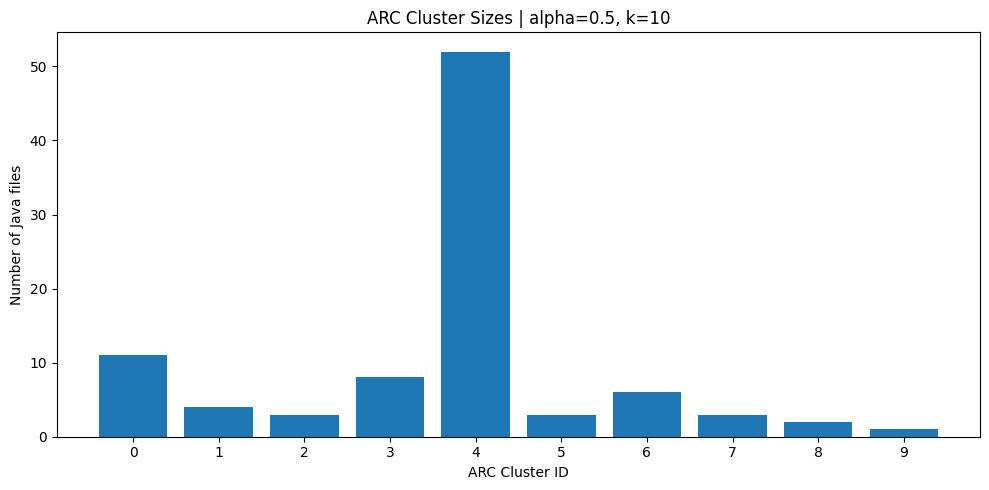

Saved plot: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_cluster_sizes.png


In [18]:
cluster_sizes = cluster_df.groupby("cluster_id").size().reset_index(name="size")

plt.figure(figsize=(10, 5))
plt.bar(cluster_sizes["cluster_id"].astype(str), cluster_sizes["size"])
plt.xlabel("ARC Cluster ID")
plt.ylabel("Number of Java files")
plt.title(f"ARC Cluster Sizes | alpha={ALPHA}, k={TARGET_NUM_CLUSTERS}")
plt.tight_layout()

plot_path = OUTPUT_DIR / f"{RUN_NAME}_cluster_sizes.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved plot:", plot_path)


## Cell 19 — Python sanity comparison with Week 2 outputs
This is not the official ARCADE `a2a/cvg`, but it checks entity overlap and similarity.


In [19]:
def parse_cluster_rsf(path):
    mapping = {}
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split()
            if len(parts) >= 3 and parts[0].lower() in {"contain", "contains"}:
                cluster = parts[1]
                entity = normalize_entity_name(parts[2])
                mapping[entity] = cluster
    return mapping

cluster_maps = {"ARC_QODO": {row["entity"]: f"ARC_Cluster_{int(row['cluster_id'])}" for _, row in cluster_df.iterrows()}}

for label, path in BASELINE_CLUSTER_FILES.items():
    cluster_maps[label] = parse_cluster_rsf(path)
    print(f"{label}: {len(cluster_maps[label])} entities parsed")

def compare_cluster_maps(name_a, map_a, name_b, map_b):
    common = sorted(set(map_a.keys()) & set(map_b.keys()))
    if len(common) < 2:
        return {
            "architecture_a": name_a,
            "architecture_b": name_b,
            "entities_a": len(map_a),
            "entities_b": len(map_b),
            "common_entities": len(common),
            "clusters_a_common": None,
            "clusters_b_common": None,
            "adjusted_rand_index": None,
            "normalized_mutual_info": None,
            "note": "Too few common entities for meaningful comparison",
        }

    labels_a_raw = [map_a[e] for e in common]
    labels_b_raw = [map_b[e] for e in common]

    def encode(labels_raw):
        lookup = {}
        encoded = []
        for x in labels_raw:
            if x not in lookup:
                lookup[x] = len(lookup)
            encoded.append(lookup[x])
        return encoded, lookup

    labels_a, lookup_a = encode(labels_a_raw)
    labels_b, lookup_b = encode(labels_b_raw)

    return {
        "architecture_a": name_a,
        "architecture_b": name_b,
        "entities_a": len(map_a),
        "entities_b": len(map_b),
        "common_entities": len(common),
        "clusters_a_common": len(lookup_a),
        "clusters_b_common": len(lookup_b),
        "adjusted_rand_index": adjusted_rand_score(labels_a, labels_b),
        "normalized_mutual_info": normalized_mutual_info_score(labels_a, labels_b),
        "note": "Python sanity check only; use ARCADE a2a/cvg for official evaluation",
    }

names = list(cluster_maps.keys())
comparison_rows = []
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        comparison_rows.append(compare_cluster_maps(names[i], cluster_maps[names[i]], names[j], cluster_maps[names[j]]))

comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(COMPARISON_CSV_OUT, index=False)

print("Comparison saved:", COMPARISON_CSV_OUT)
comparison_df


WCA_UEM: 343 entities parsed
WCA_UEMNM: 343 entities parsed


LIMBO_IL: 343 entities parsed
Comparison saved: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_python_comparison_sanity.csv


/pc2/users/r/rohit/.local/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)
/pc2/users/r/rohit/.local/lib/python3.10/site-packages/sklearn/metrics/cluster/_supervised.py:49: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_label = type_of_target(labels_true)


,architecture_a,architecture_b,entities_a,entities_b,common_entities,clusters_a_common,clusters_b_common,adjusted_rand_index,normalized_mutual_info,note
0,ARC_QODO,WCA_UEM,93,343,53,2.0,25.0,0.003440,0.060624,Python sanity check only; use ARCADE a2a/cvg f...
1,ARC_QODO,WCA_UEMNM,93,343,53,2.0,1.0,0.000000,0.000000,Python sanity check only; use ARCADE a2a/cvg f...
2,ARC_QODO,LIMBO_IL,93,343,0,NaN,NaN,NaN,NaN,Too few common entities for meaningful comparison
3,WCA_UEM,WCA_UEMNM,343,343,343,213.0,10.0,0.009432,0.273797,Python sanity check only; use ARCADE a2a/cvg f...
4,WCA_UEM,LIMBO_IL,343,343,0,NaN,NaN,NaN,NaN,Too few common entities for meaningful comparison
5,WCA_UEMNM,LIMBO_IL,343,343,0,NaN,NaN,NaN,NaN,Too few common entities for meaningful comparison


## Cell 20 — Write summary file


In [20]:
summary_text = f"""
DS4SE26 Week 3 ARC Run Summary
==============================

Working directory:
{WORK_DIR}

Input files:
Focused dependency RSF: {FOCUSED_DEPENDENCY_RSF}
WCA_UEM: {BASELINE_CLUSTER_FILES['WCA_UEM']}
WCA_UEMNM: {BASELINE_CLUSTER_FILES['WCA_UEMNM']}
LIMBO_IL: {BASELINE_CLUSTER_FILES['LIMBO_IL']}

Model:
{EMBEDDING_MODEL_NAME}

Lucene source tag/branch:
{LUCENE_GIT_TAG}

ARC settings:
ALPHA = {ALPHA}
TARGET_NUM_CLUSTERS = {TARGET_NUM_CLUSTERS}
BATCH_SIZE = {BATCH_SIZE}
MAX_TOKENS = {MAX_TOKENS}

Counts:
Java source files used = {len(entities)}
Focused RSF dependency edges = {len(dependency_edges)}
Unique RSF entities = {len(rsf_entities)}
Source entities overlapping with focused RSF = {len(overlap_with_rsf)}

Outputs:
ARC RSF = {ARC_RSF_OUT}
ARC CSV = {ARC_CSV_OUT}
Embeddings = {embeddings_path}
Semantic matrix = {semantic_path}
Structural matrix = {structural_path}
Combined matrix = {combined_path}
Distance matrix = {distance_path}
Comparison sanity CSV = {COMPARISON_CSV_OUT}
Cluster size plot = {plot_path}

Important:
The Python comparison table is only a sanity check.
For official Week 3 evaluation, also run ARCADE a2a and cvg using:
- ARC output
- wca_uem.rsf
- wca_uemnm.rsf
- limbo_il.rsf
"""

SUMMARY_OUT.write_text(summary_text, encoding="utf-8")
print("Summary saved:", SUMMARY_OUT)
print(summary_text)


Summary saved: /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_summary.txt

DS4SE26 Week 3 ARC Run Summary

Working directory:
/scratch/hpc-prf-dssecs/group4

Input files:
Focused dependency RSF: /scratch/hpc-prf-dssecs/group4/input/lucene-codecs-focused.rsf
WCA_UEM: /scratch/hpc-prf-dssecs/group4/input/wca_uem.rsf
WCA_UEMNM: /scratch/hpc-prf-dssecs/group4/input/wca_uemnm.rsf
LIMBO_IL: /scratch/hpc-prf-dssecs/group4/input/limbo_il.rsf

Model:
Qodo/Qodo-Embed-1-7B

Lucene source tag/branch:
releases/lucene/9.10.0

ARC settings:
ALPHA = 0.5
TARGET_NUM_CLUSTERS = 10
BATCH_SIZE = 1
MAX_TOKENS = 1024

Counts:
Java source files used = 93
Focused RSF dependency edges = 1947
Unique RSF entities = 343
Source entities overlapping with focused RSF = 53

Outputs:
ARC RSF = /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_clusters.rsf
ARC CSV = /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_alpha0_5_k10_clusters.csv
Embeddings = /scratch/hpc-prf-dssecs/group4/output/ARC_Qodo_

## Cell 21 — Prepare ARCADE a2a/cvg evaluation folder
This creates `/scratch/hpc-prf-dssecs/group4/arcade_eval` and copies the final RSF files there.


In [21]:
TOOLS_DIR = EVAL_DIR / "tools"
RSF_DIR = EVAL_DIR / "rsf"
RESULTS_DIR = EVAL_DIR / "results"

for d in [TOOLS_DIR, RSF_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Copy files for evaluation
shutil.copy2(ARC_RSF_OUT, RSF_DIR / "arc_qodo.rsf")
shutil.copy2(BASELINE_CLUSTER_FILES["WCA_UEM"], RSF_DIR / "wca_uem.rsf")
shutil.copy2(BASELINE_CLUSTER_FILES["WCA_UEMNM"], RSF_DIR / "wca_uemnm.rsf")
shutil.copy2(BASELINE_CLUSTER_FILES["LIMBO_IL"], RSF_DIR / "limbo_il.rsf")

print("ARCADE eval folder:", EVAL_DIR)
print("Upload a2a/cvg jar files here:", TOOLS_DIR)
print("RSF files:")
for p in sorted(RSF_DIR.glob("*.rsf")):
    print(" -", p.name, p.stat().st_size, "bytes")


ARCADE eval folder: /scratch/hpc-prf-dssecs/group4/arcade_eval
Upload a2a/cvg jar files here: /scratch/hpc-prf-dssecs/group4/arcade_eval/tools
RSF files:
 - arc_qodo.rsf 7408 bytes
 - limbo_il.rsf 42013 bytes
 - wca_uem.rsf 23349 bytes
 - wca_uemnm.rsf 22550 bytes


## Cell 22 — Detect a2a/cvg tools and generate command script
Upload your ARCADE a2a and cvg `.jar` files into the `tools` folder before running this cell.


In [22]:
from itertools import combinations

all_jars = list(TOOLS_DIR.glob("*.jar"))
print("JAR files found:")
for jar in all_jars:
    print(" -", jar.name)

a2a_candidates = [j for j in all_jars if "a2a" in j.name.lower()]
cvg_candidates = [j for j in all_jars if "cvg" in j.name.lower() or "coverage" in j.name.lower()]

if not a2a_candidates:
    raise FileNotFoundError(f"No a2a jar found in {TOOLS_DIR}. Rename/upload so filename contains 'a2a'.")
if not cvg_candidates:
    raise FileNotFoundError(f"No cvg jar found in {TOOLS_DIR}. Rename/upload so filename contains 'cvg'.")

A2A_JAR = a2a_candidates[0]
CVG_JAR = cvg_candidates[0]
print("A2A_JAR:", A2A_JAR)
print("CVG_JAR:", CVG_JAR)

rsf_files = {
    "ARC_QODO": RSF_DIR / "arc_qodo.rsf",
    "WCA_UEM": RSF_DIR / "wca_uem.rsf",
    "WCA_UEMNM": RSF_DIR / "wca_uemnm.rsf",
    "LIMBO_IL": RSF_DIR / "limbo_il.rsf",
}
comparison_pairs = list(combinations(rsf_files.items(), 2))
commands_file = RESULTS_DIR / "arcade_eval_commands.sh"

with open(commands_file, "w", encoding="utf-8") as f:
    f.write("#!/bin/bash\n")
    f.write("set -e\n\n")
    f.write(f"cd {EVAL_DIR}\n\n")

    for (name_a, path_a), (name_b, path_b) in comparison_pairs:
        pair_name = f"{name_a}_VS_{name_b}"

        a2a_out = RESULTS_DIR / f"{pair_name}_a2a.txt"
        cvg_out = RESULTS_DIR / f"{pair_name}_cvg.txt"

        f.write(f"echo 'A2A: {pair_name}'\n")
        f.write(f"java -jar {A2A_JAR} {path_a} {path_b} > {a2a_out} 2>&1\n\n")

        f.write(f"echo 'CVG: {pair_name}'\n")
        f.write(f"java -jar {CVG_JAR} {path_a} {path_b} > {cvg_out} 2>&1\n\n")

commands_file.chmod(0o755)

print("Command script created:", commands_file)
print(commands_file.read_text())


JAR files found:
 - arcade_core_Cvg.jar
 - arcade_core_A2a.jar
A2A_JAR: /scratch/hpc-prf-dssecs/group4/arcade_eval/tools/arcade_core_A2a.jar
CVG_JAR: /scratch/hpc-prf-dssecs/group4/arcade_eval/tools/arcade_core_Cvg.jar


Command script created: /scratch/hpc-prf-dssecs/group4/arcade_eval/results/arcade_eval_commands.sh
#!/bin/bash
set -e

cd /scratch/hpc-prf-dssecs/group4/arcade_eval

echo 'A2A: ARC_QODO_VS_WCA_UEM'
java -jar /scratch/hpc-prf-dssecs/group4/arcade_eval/tools/arcade_core_A2a.jar /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/arc_qodo.rsf /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/wca_uem.rsf > /scratch/hpc-prf-dssecs/group4/arcade_eval/results/ARC_QODO_VS_WCA_UEM_a2a.txt 2>&1

echo 'CVG: ARC_QODO_VS_WCA_UEM'
java -jar /scratch/hpc-prf-dssecs/group4/arcade_eval/tools/arcade_core_Cvg.jar /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/arc_qodo.rsf /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/wca_uem.rsf > /scratch/hpc-prf-dssecs/group4/arcade_eval/results/ARC_QODO_VS_WCA_UEM_cvg.txt 2>&1

echo 'A2A: ARC_QODO_VS_WCA_UEMNM'
java -jar /scratch/hpc-prf-dssecs/group4/arcade_eval/tools/arcade_core_A2a.jar /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/arc_qodo.rsf /scratch/hpc-prf-dssecs/gro

## Cell 23 — Run ARCADE a2a/cvg comparisons
Run this only after Cell 22 succeeds.


In [23]:
result = subprocess.run(["bash", str(commands_file)], stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
print("STDOUT:")
print(result.stdout)
print("STDERR:")
print(result.stderr)
print("Return code:", result.returncode)

print("Generated result files:")
for p in sorted(RESULTS_DIR.glob("*.txt")):
    print(" -", p.name, p.stat().st_size, "bytes")

if result.returncode != 0:
    print("One of the commands failed. Open the result text files to see the exact ARCADE usage error.")


STDOUT:
A2A: ARC_QODO_VS_WCA_UEM
CVG: ARC_QODO_VS_WCA_UEM
A2A: ARC_QODO_VS_WCA_UEMNM
CVG: ARC_QODO_VS_WCA_UEMNM
A2A: ARC_QODO_VS_LIMBO_IL
CVG: ARC_QODO_VS_LIMBO_IL
A2A: WCA_UEM_VS_WCA_UEMNM
CVG: WCA_UEM_VS_WCA_UEMNM
A2A: WCA_UEM_VS_LIMBO_IL
CVG: WCA_UEM_VS_LIMBO_IL
A2A: WCA_UEMNM_VS_LIMBO_IL
CVG: WCA_UEMNM_VS_LIMBO_IL

STDERR:

Return code: 0
Generated result files:
 - ARC_QODO_VS_LIMBO_IL_a2a.txt 20 bytes
 - ARC_QODO_VS_LIMBO_IL_cvg.txt 288 bytes
 - ARC_QODO_VS_WCA_UEMNM_a2a.txt 20 bytes
 - ARC_QODO_VS_WCA_UEMNM_cvg.txt 290 bytes
 - ARC_QODO_VS_WCA_UEM_a2a.txt 20 bytes
 - ARC_QODO_VS_WCA_UEM_cvg.txt 286 bytes
 - WCA_UEMNM_VS_LIMBO_IL_a2a.txt 19 bytes
 - WCA_UEMNM_VS_LIMBO_IL_cvg.txt 290 bytes
 - WCA_UEM_VS_LIMBO_IL_a2a.txt 18 bytes
 - WCA_UEM_VS_LIMBO_IL_cvg.txt 286 bytes
 - WCA_UEM_VS_WCA_UEMNM_a2a.txt 18 bytes
 - WCA_UEM_VS_WCA_UEMNM_cvg.txt 304 bytes


## Cell 24 — Combine a2a/cvg result files into one summary


In [24]:
combined_eval_summary = RESULTS_DIR / "week3_arcade_a2a_cvg_summary.txt"

with open(combined_eval_summary, "w", encoding="utf-8") as out:
    out.write("Week 3 ARCADE a2a/cvg Evaluation Summary\n")
    out.write("=" * 60 + "\n\n")

    result_files = sorted(RESULTS_DIR.glob("*.txt"))

    for p in result_files:
        if p.name == combined_eval_summary.name:
            continue

        out.write("\n" + "=" * 80 + "\n")
        out.write(f"{p.name}\n")
        out.write("=" * 80 + "\n\n")

        content = p.read_text(encoding="utf-8", errors="ignore")
        out.write(content)
        out.write("\n\n")

print("Combined summary saved:", combined_eval_summary)
print(combined_eval_summary.read_text(encoding="utf-8", errors="ignore")[:3000])


Combined summary saved: /scratch/hpc-prf-dssecs/group4/arcade_eval/results/week3_arcade_a2a_cvg_summary.txt
Week 3 ARCADE a2a/cvg Evaluation Summary


ARC_QODO_VS_LIMBO_IL_a2a.txt

0.28612303290415086



ARC_QODO_VS_LIMBO_IL_cvg.txt

Coverage from /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/arc_qodo.rsf to /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/limbo_il.rsf is 0.0
Coverage from /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/limbo_il.rsf to /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/arc_qodo.rsf is 0.0



ARC_QODO_VS_WCA_UEMNM_a2a.txt

0.28612303290415086



ARC_QODO_VS_WCA_UEMNM_cvg.txt

Coverage from /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/arc_qodo.rsf to /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/wca_uemnm.rsf is 0.0
Coverage from /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/wca_uemnm.rsf to /scratch/hpc-prf-dssecs/group4/arcade_eval/rsf/arc_qodo.rsf is 0.0



ARC_QODO_VS_WCA_UEM_a2a.txt

0.22172949002217113



ARC_QODO_VS_WCA_UEM_cvg.txt

Coverage from /s

In [25]:
# ============================================================
# WEEK 3 ARC VISUALISATIONS
# Saves all plots to output/visualisations
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

WORK_DIR = Path("/scratch/hpc-prf-dssecs/group4")
OUTPUT_DIR = WORK_DIR / "output"
VIS_DIR = OUTPUT_DIR / "visualisations"
VIS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "ARC_Qodo_alpha0_5_k10"

embeddings_file = OUTPUT_DIR / f"{RUN_NAME}_embeddings.npy"
semantic_file = OUTPUT_DIR / f"{RUN_NAME}_semantic_similarity_matrix.npy"
structural_file = OUTPUT_DIR / f"{RUN_NAME}_structural_similarity_matrix.npy"
combined_file = OUTPUT_DIR / f"{RUN_NAME}_combined_similarity_matrix.npy"
distance_file = OUTPUT_DIR / f"{RUN_NAME}_distance_matrix.npy"
clusters_csv = OUTPUT_DIR / f"{RUN_NAME}_clusters.csv"
sanity_csv = OUTPUT_DIR / f"{RUN_NAME}_python_comparison_sanity.csv"

print("Visualisation output folder:", VIS_DIR)

# ------------------------------------------------------------
# 2. Helper functions
# ------------------------------------------------------------

def save_heatmap(matrix_path, title, output_name, value_label="Similarity"):
    matrix_path = Path(matrix_path)

    if not matrix_path.exists():
        print("Skipping missing file:", matrix_path)
        return

    matrix = np.load(matrix_path)

    plt.figure(figsize=(9, 7))
    plt.imshow(matrix, aspect="auto")
    plt.colorbar(label=value_label)
    plt.title(title)
    plt.xlabel("Entity index")
    plt.ylabel("Entity index")
    plt.tight_layout()

    out_path = VIS_DIR / output_name
    plt.savefig(out_path, dpi=300)
    plt.close()

    print("Saved:", out_path)


def save_bar_chart(df, x_col, y_col, title, xlabel, ylabel, output_name, rotate=True):
    if df.empty:
        print("Skipping empty dataframe for:", title)
        return

    plt.figure(figsize=(10, 6))
    plt.bar(df[x_col].astype(str), df[y_col])
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if rotate:
        plt.xticks(rotation=45, ha="right")

    plt.tight_layout()

    out_path = VIS_DIR / output_name
    plt.savefig(out_path, dpi=300)
    plt.close()

    print("Saved:", out_path)


# ------------------------------------------------------------
# 3. Heatmaps: semantic, structural, combined, distance
# ------------------------------------------------------------

save_heatmap(
    semantic_file,
    "Semantic similarity matrix from Qodo embeddings",
    "semantic_similarity_heatmap.png",
    "Semantic similarity"
)

save_heatmap(
    structural_file,
    "Structural similarity matrix from filtered RSF dependencies",
    "structural_similarity_heatmap.png",
    "Structural similarity"
)

save_heatmap(
    combined_file,
    "Combined ARC similarity matrix",
    "combined_similarity_heatmap.png",
    "Combined similarity"
)

save_heatmap(
    distance_file,
    "Distance matrix used for Agglomerative Clustering",
    "distance_matrix_heatmap.png",
    "Distance"
)

# ------------------------------------------------------------
# 4. PCA scatter plot of embeddings colored by ARC cluster
# ------------------------------------------------------------

if embeddings_file.exists() and clusters_csv.exists():
    embeddings = np.load(embeddings_file)
    cluster_df = pd.read_csv(clusters_csv)

    if "cluster_id" not in cluster_df.columns:
        raise ValueError("clusters.csv must contain a cluster_id column.")

    pca = PCA(n_components=2, random_state=42)
    points_2d = pca.fit_transform(embeddings)

    plot_df = pd.DataFrame({
        "PC1": points_2d[:, 0],
        "PC2": points_2d[:, 1],
        "cluster_id": cluster_df["cluster_id"].values
    })

    plt.figure(figsize=(9, 7))

    for cluster_id in sorted(plot_df["cluster_id"].unique()):
        subset = plot_df[plot_df["cluster_id"] == cluster_id]
        plt.scatter(
            subset["PC1"],
            subset["PC2"],
            label=f"Cluster {cluster_id}",
            alpha=0.8,
            s=35
        )

    plt.title("PCA projection of Qodo embeddings colored by ARC cluster")
    plt.xlabel("Principal component 1")
    plt.ylabel("Principal component 2")
    plt.legend(fontsize=8, loc="best")
    plt.tight_layout()

    out_path = VIS_DIR / "pca_embeddings_by_arc_cluster.png"
    plt.savefig(out_path, dpi=300)
    plt.close()

    print("Saved:", out_path)
else:
    print("Skipping PCA plot because embeddings or cluster CSV is missing.")

# ------------------------------------------------------------
# 5. Common entity overlap bar chart
# ------------------------------------------------------------

if sanity_csv.exists():
    sanity_df = pd.read_csv(sanity_csv)

    if "architecture_a" in sanity_df.columns and "architecture_b" in sanity_df.columns:
        sanity_df["comparison_pair"] = sanity_df["architecture_a"].astype(str) + " vs " + sanity_df["architecture_b"].astype(str)

    if "common_entities" in sanity_df.columns:
        overlap_df = sanity_df[["comparison_pair", "common_entities"]].copy()
        overlap_df = overlap_df.sort_values("common_entities", ascending=True)

        save_bar_chart(
            overlap_df,
            "comparison_pair",
            "common_entities",
            "Common entity overlap across cluster outputs",
            "Comparison pair",
            "Common entities",
            "common_entity_overlap_bar_chart.png",
            rotate=True
        )
    else:
        print("Skipping overlap chart because common_entities column is missing.")
else:
    print("Skipping sanity comparison plots because sanity CSV is missing.")

# ------------------------------------------------------------
# 6. ARI and NMI comparison heatmap-style charts
# ------------------------------------------------------------

if sanity_csv.exists():
    sanity_df = pd.read_csv(sanity_csv)

    if "architecture_a" in sanity_df.columns and "architecture_b" in sanity_df.columns:
        sanity_df["comparison_pair"] = sanity_df["architecture_a"].astype(str) + " vs " + sanity_df["architecture_b"].astype(str)

    metric_cols = []

    if "adjusted_rand_index" in sanity_df.columns:
        metric_cols.append("adjusted_rand_index")

    if "normalized_mutual_info" in sanity_df.columns:
        metric_cols.append("normalized_mutual_info")

    if metric_cols:
        metric_df = sanity_df[["comparison_pair"] + metric_cols].copy()
        metric_df = metric_df.dropna()

        if not metric_df.empty:
            metric_values = metric_df[metric_cols].values

            plt.figure(figsize=(8, max(4, len(metric_df) * 0.6)))
            plt.imshow(metric_values, aspect="auto")
            plt.colorbar(label="Score")
            plt.yticks(range(len(metric_df)), metric_df["comparison_pair"])
            plt.xticks(range(len(metric_cols)), metric_cols, rotation=30, ha="right")
            plt.title("Python sanity comparison: ARI and NMI")
            plt.tight_layout()

            out_path = VIS_DIR / "ari_nmi_comparison_heatmap.png"
            plt.savefig(out_path, dpi=300)
            plt.close()

            print("Saved:", out_path)
        else:
            print("Skipping ARI/NMI heatmap because all metric rows are empty.")
    else:
        print("Skipping ARI/NMI heatmap because metric columns are missing.")
else:
    print("Skipping ARI/NMI heatmap because sanity CSV is missing.")

# ------------------------------------------------------------
# 7. ARC pipeline flow diagram
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis("off")

boxes = [
    {
        "label": "Filtered dependency RSF\nlucene-codecs-focused.rsf",
        "xy": (0.05, 0.70)
    },
    {
        "label": "Structural similarity matrix\nfrom dependency relationships",
        "xy": (0.30, 0.70)
    },
    {
        "label": "Java source files\nLucene Codecs component",
        "xy": (0.05, 0.35)
    },
    {
        "label": "Qodo embeddings\nQodo/Qodo-Embed-1-7B",
        "xy": (0.30, 0.35)
    },
    {
        "label": "Semantic similarity matrix\ncosine similarity",
        "xy": (0.55, 0.35)
    },
    {
        "label": "Combined similarity matrix\nalpha = 0.5",
        "xy": (0.55, 0.70)
    },
    {
        "label": "Distance matrix\n1 - combined similarity",
        "xy": (0.78, 0.70)
    },
    {
        "label": "Agglomerative clustering\nk = 10",
        "xy": (0.78, 0.35)
    },
    {
        "label": "ARC output clusters\nARC_Qodo_alpha0_5_k10_clusters.rsf",
        "xy": (0.55, 0.05)
    },
    {
        "label": "Compare with baselines\nWCA-UEM, WCA-UEMNM, LIMBO-IL",
        "xy": (0.30, 0.05)
    }
]

box_width = 0.18
box_height = 0.13

for box in boxes:
    x, y = box["xy"]
    rect = plt.Rectangle(
        (x, y),
        box_width,
        box_height,
        fill=False,
        linewidth=1.5
    )
    ax.add_patch(rect)
    ax.text(
        x + box_width / 2,
        y + box_height / 2,
        box["label"],
        ha="center",
        va="center",
        fontsize=9
    )

def arrow(start, end):
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", linewidth=1.5)
    )

# Top structural path
arrow((0.23, 0.765), (0.30, 0.765))
arrow((0.48, 0.765), (0.55, 0.765))

# Semantic path
arrow((0.23, 0.415), (0.30, 0.415))
arrow((0.48, 0.415), (0.55, 0.415))

# Combine to distance and clustering
arrow((0.73, 0.765), (0.78, 0.765))
arrow((0.87, 0.70), (0.87, 0.48))

# Output and comparison
arrow((0.78, 0.35), (0.66, 0.18))
arrow((0.55, 0.115), (0.48, 0.115))

ax.set_title("Week 3 ARC clustering pipeline for Apache Lucene Codecs", fontsize=14, pad=20)

flow_path = VIS_DIR / "arc_pipeline_flow_diagram.png"
plt.tight_layout()
plt.savefig(flow_path, dpi=300)
plt.close()

print("Saved:", flow_path)

# ------------------------------------------------------------
# 8. Final list
# ------------------------------------------------------------

print("\nGenerated visualisation files:")
for p in sorted(VIS_DIR.glob("*.png")):
    print(" -", p.name)

Visualisation output folder: /scratch/hpc-prf-dssecs/group4/output/visualisations


Saved: /scratch/hpc-prf-dssecs/group4/output/visualisations/semantic_similarity_heatmap.png


Saved: /scratch/hpc-prf-dssecs/group4/output/visualisations/structural_similarity_heatmap.png


Saved: /scratch/hpc-prf-dssecs/group4/output/visualisations/combined_similarity_heatmap.png


Saved: /scratch/hpc-prf-dssecs/group4/output/visualisations/distance_matrix_heatmap.png


Saved: /scratch/hpc-prf-dssecs/group4/output/visualisations/pca_embeddings_by_arc_cluster.png


Saved: /scratch/hpc-prf-dssecs/group4/output/visualisations/common_entity_overlap_bar_chart.png


Saved: /scratch/hpc-prf-dssecs/group4/output/visualisations/ari_nmi_comparison_heatmap.png


Saved: /scratch/hpc-prf-dssecs/group4/output/visualisations/arc_pipeline_flow_diagram.png

Generated visualisation files:
 - arc_pipeline_flow_diagram.png
 - ari_nmi_comparison_heatmap.png
 - combined_similarity_heatmap.png
 - common_entity_overlap_bar_chart.png
 - distance_matrix_heatmap.png
 - pca_embeddings_by_arc_cluster.png
 - semantic_similarity_heatmap.png
 - structural_similarity_heatmap.png
